<a href="https://colab.research.google.com/github/gforconi/UTNIA2025/blob/main/CNN_2026/Clasificador_Frutas_UTN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🍎 Clasificación de Frutas con Redes Neuronales Convolucionales
## Universidad Tecnológica Nacional – Regional Rosario
### Materia: Inteligencia Artificial | PyTorch 2.x

---

## Objetivos
1. Preparar y explorar un dataset de imágenes de frutas
2. Diseñar una CNN desde cero con PyTorch
3. Entrenar, evaluar y visualizar predicciones
4. Comparar resultados entre un dataset controlado y uno realista

## Estrategia: dos datasets, dos mundos

| Etapa | Dataset | Objetivo pedagógico |
|-------|---------|---------------------|
| **Etapa 1** | UTN-IA 2026 · Estudio Visual - Etapa 1 | Introducir CNNs, obtener ~95% accuracy rápido |
| **Etapa 2** | UTN-IA 2026 · Food Classification - Training Set | Generalización, overfitting, data augmentation |

> **Pregunta disparadora:** ¿Por qué la misma arquitectura puede obtener 95% en un dataset y solo 70% en otro?


## Celda 0: Configuración del entorno

In [1]:
import torch

# Verificar disponibilidad de GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memoria: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('No se detectó GPU. En Colab: Entorno de ejecución → Cambiar tipo → GPU T4')


Dispositivo: cpu
No se detectó GPU. En Colab: Entorno de ejecución → Cambiar tipo → GPU T4


In [2]:
# Instalar dependencias adicionales
#!pip install -q kaggle scikit-learn seaborn

import os, shutil, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from sklearn.metrics import classification_report, confusion_matrix

# Semilla para reproducibilidad
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed(SEED)

print(f'PyTorch {torch.__version__} | Torchvision {torchvision.__version__}')
print('✅ Librerías importadas')


PyTorch 2.12.0+cpu | Torchvision 0.27.0+cpu
✅ Librerías importadas


---
# 🍊 ETAPA 1: UTN-IA 2026 · Estudio Visual - Etapa 1
## Dataset controlado para aprender los fundamentos

**UTN-IA 2026 · Estudio Visual - Etapa 1** tiene imágenes sobre fondo blanco uniforme. Ideal para introducir CNN porque:
- Las imágenes son muy distintas entre clases → fácil de clasificar
- El modelo alcanza ~95% rápidamente → resultados exitosos en clase
- Permite enfocarse en la arquitectura, no en el preprocesamiento

**Link Kaggle:** https://www.kaggle.com/datasets/geronimoforconi/utn-ia-2026-estudio-visual-etapa-1  
**Licencia:** Apache 2.0


### Paso 1.1: Descarga del dataset

Para descargar desde Kaggle necesitás una API key:
1. Ir a kaggle.com → tu perfil → Settings → API → Create New Token
2. Copiar `API TOKEN`
3. Subirlo con la celda de abajo


In [3]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_b983894342aafc292b626934d1c0e135"



In [4]:
# Descargar UTN-IA 2026 · Estudio Visual - Etapa 1 desde Kaggle
!kaggle datasets download -d geronimoforconi/utn-ia-2026-estudio-visual-etapa-1 -p /Users/Admin/Desktop/Estudios/Sistemas-2026/IA/Practica/Clase_3 --unzip -q
print("✅ Dataset Estudio Visual - Etapa 1 descargado")


Dataset URL: https://www.kaggle.com/datasets/geronimoforconi/utn-ia-2026-estudio-visual-etapa-1
License(s): CC-BY-NC-SA-4.0
✅ Dataset Estudio Visual - Etapa 1 descargado


In [5]:
# ============================================================
# Seleccionamos 5 clases — el dataset ya tiene train/val/test separados
# ============================================================
CLASES_SELECCIONADAS = ['Apple Golden 1', 'Banana 1', 'Grape Blue 1', 'Strawberry 1', 'Cherry 1']
DATASET_RAIZ = '/Users/Admin/Desktop/Estudios/Sistemas-2026/IA/Practica/Clase_3/notebook_frutas_estudio/'
BASE_DIR = Path('/Users/Admin/Desktop/Estudios/Sistemas-2026/IA/Practica/Clase_3/frutas_seleccionadas')

def crear_subset(clases, raiz, destino):
    """Copia las clases seleccionadas desde cada split ya separado (train/val/test)."""
    for split in ['train', 'val', 'test']:
        src_base = Path(raiz) / split
        if not src_base.exists():
            print(f"⚠️  No se encontró {src_base}, saltando...")
            continue
        for clase in clases:
            src_dir = src_base / clase
            if not src_dir.exists():
                print(f"⚠️  Clase {clase} no encontrada en {split}/")
                continue
            dst = destino / split / clase
            dst.mkdir(parents=True, exist_ok=True)
            for img in src_dir.glob("*.*"):
                if img.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                    shutil.copy(img, dst / img.name)
    print(f"✅ Subset creado en {destino}")

crear_subset(CLASES_SELECCIONADAS, DATASET_RAIZ, BASE_DIR)


✅ Subset creado en \Users\Admin\Desktop\Estudios\Sistemas-2026\IA\Practica\Clase_3\frutas_seleccionadas


### Paso 1.2: Exploración visual del dataset

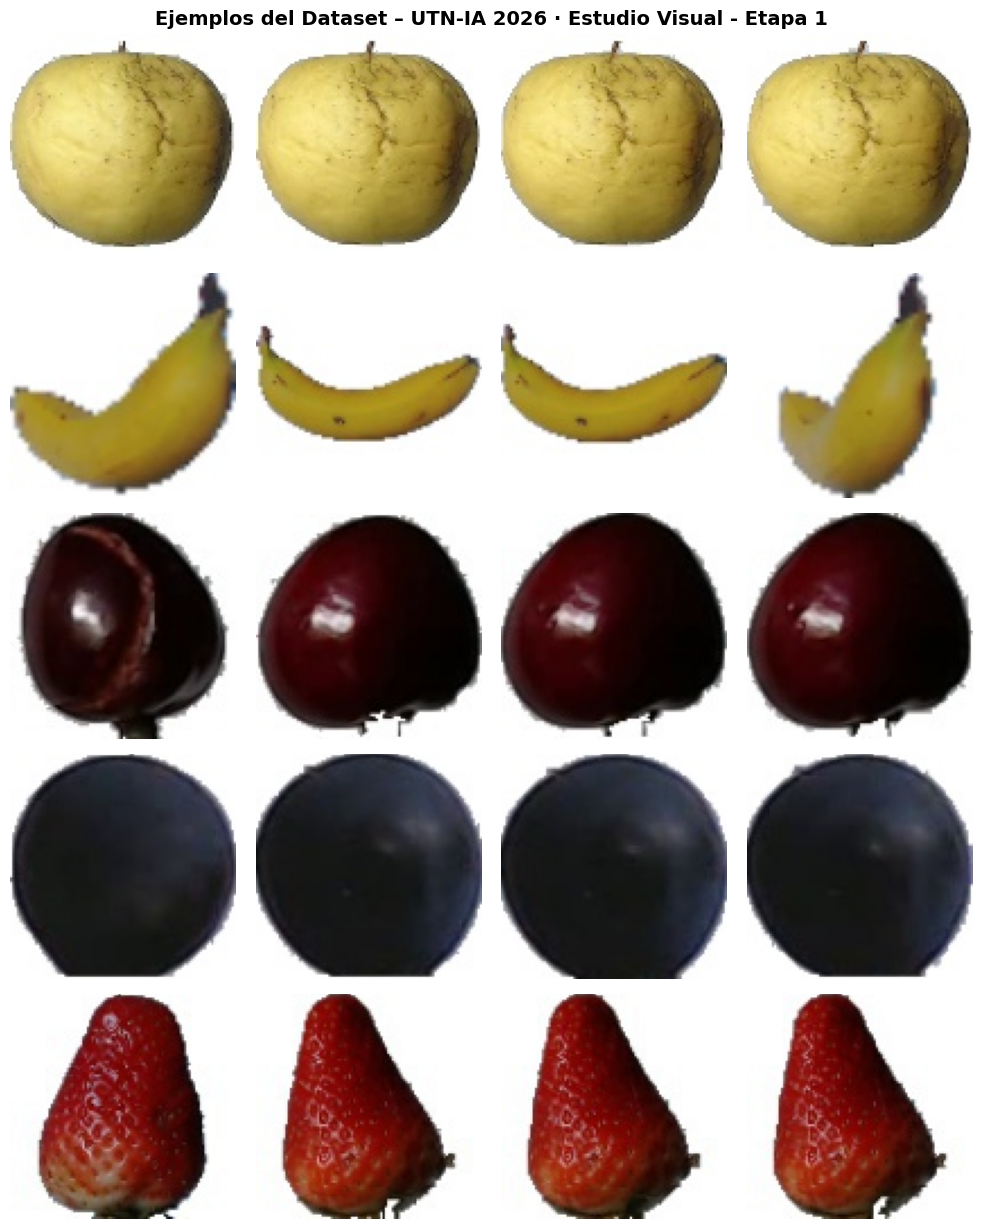

In [6]:
def mostrar_ejemplos(base_dir, split='train', n=4):
    clases = sorted(os.listdir(base_dir / split))
    fig, axes = plt.subplots(len(clases), n, figsize=(n*2.5, len(clases)*2.5))
    fig.suptitle('Ejemplos del Dataset – UTN-IA 2026 · Estudio Visual - Etapa 1', fontsize=14, fontweight='bold')
    for i, clase in enumerate(clases):
        imgs = list((base_dir / split / clase).glob('*.jpg'))[:n]
        for j, p in enumerate(imgs):
            axes[i][j].imshow(Image.open(p))
            axes[i][j].axis('off')
            if j == 0:
                axes[i][j].set_ylabel(clase.split()[0], fontsize=10, fontweight='bold')
    plt.tight_layout(); plt.show()

mostrar_ejemplos(BASE_DIR)


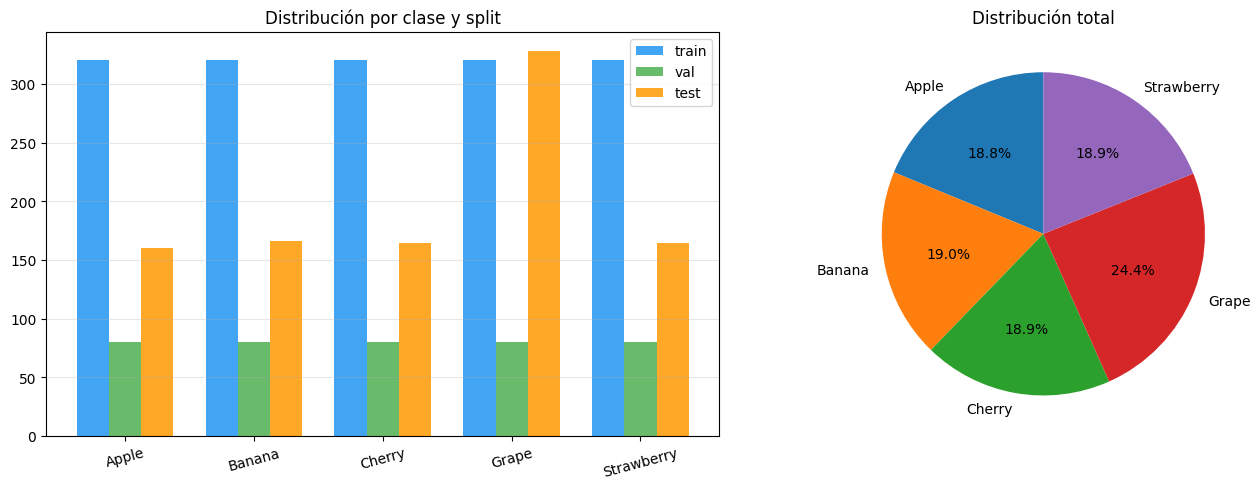

Clase                     Train      Val     Test
--------------------------------------------------
Apple Golden 1              320       80      160
Banana 1                    320       80      166
Cherry 1                    320       80      164
Grape Blue 1                320       80      328
Strawberry 1                320       80      164


In [7]:
def analizar_distribucion(base_dir):
    splits = ['train', 'val', 'test']
    conteos = {s: {} for s in splits}
    for s in splits:
        sd = base_dir / s
        if sd.exists():
            for c in os.listdir(sd):
                conteos[s][c] = len(list((sd/c).glob('*.jpg')))

    clases = list(conteos['train'].keys())
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    x = np.arange(len(clases)); w = 0.25
    for idx, (s, col) in enumerate(zip(splits, ['#2196F3','#4CAF50','#FF9800'])):
        ax1.bar(x + idx*w, [conteos[s].get(c,0) for c in clases], w, label=s, color=col, alpha=0.85)
    ax1.set_xticks(x+w); ax1.set_xticklabels([c.split()[0] for c in clases], rotation=15)
    ax1.set_title('Distribución por clase y split'); ax1.legend(); ax1.grid(axis='y', alpha=0.3)

    totales = {c: sum(conteos[s].get(c,0) for s in splits) for c in clases}
    ax2.pie(totales.values(), labels=[c.split()[0] for c in clases], autopct='%1.1f%%', startangle=90)
    ax2.set_title('Distribución total')
    plt.tight_layout(); plt.show()

    print(f'{"Clase":<22} {"Train":>8} {"Val":>8} {"Test":>8}')
    print('-'*50)
    for c in clases:
        print(f'{c:<22} {conteos["train"].get(c,0):>8} {conteos["val"].get(c,0):>8} {conteos["test"].get(c,0):>8}')

analizar_distribucion(BASE_DIR)


### Paso 1.3: Preprocesamiento y Data Augmentation

Las CNNs esperan tensores normalizados. Definimos dos pipelines:
- **transform_base**: solo lo esencial (resize, tensor, normalize) → para val/test
- **transform_train**: agrega variaciones aleatorias → solo para entrenamiento

Los valores `mean=[0.485, 0.456, 0.406]` y `std=[0.229, 0.224, 0.225]` son los de ImageNet. Son los parámetros de normalización por canal RGB, calculados originalmente sobre el dataset ImageNet (1.2 millones de imágenes).

**Data Augmentation:**

Aplica solo al training set, nunca a val ni test. El objetivo es que en cada epoch el modelo vea versiones ligeramente distintas de la misma imagen, lo que actúa como regularización — el modelo no puede memorizar las imágenes de entrenamiento porque cada vez son un poco diferentes.
El efecto es equivalente a tener más datos sin recolectar nada nuevo.

In [17]:
IMG_SIZE   = 64
BATCH_SIZE = 32
NUM_CLASES = 5
# Ponemos estos valores para no calcularlos
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# Pipeline base: val y test
transform_base = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

# Pipeline con augmentation: solo training
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE + 8, IMG_SIZE + 8)),   # → 72×72
    transforms.RandomCrop(IMG_SIZE),                   # → recorta 64×64 al azar
    transforms.RandomHorizontalFlip(p=0.5),            # → espejo horizontal, 50% de chances
    transforms.RandomRotation(degrees=15),             # → rota entre -15° y +15°
    transforms.ColorJitter(brightness=0.3,             # → varía brillo
                          contrast=0.3,                # → varía contraste
                          saturation=0.2,              # → varía saturación
                          hue=0.1),                    # → varía tono de color
    transforms.ToTensor(),                             # → Convierte a tensor
    transforms.Normalize(mean=MEAN, std=STD)           # → Normaliza
])

print('✅ Transformaciones definidas')
print('   Train: resize+crop+flip+rotación+colorjitter+normalize')
print('   Val/Test: solo resize+normalize')


✅ Transformaciones definidas
   Train: resize+crop+flip+rotación+colorjitter+normalize
   Val/Test: solo resize+normalize


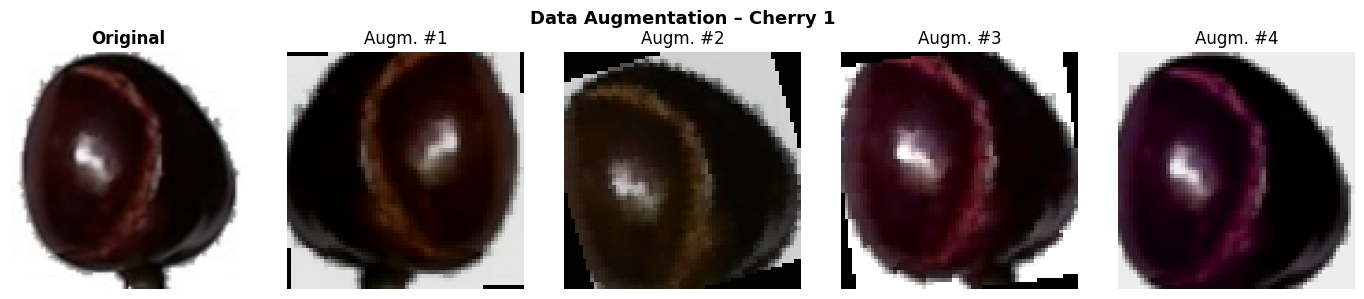

In [18]:
def visualizar_augmentation(base_dir, clase, n=4):
    """Muestra la misma imagen con distintas augmentaciones."""
    carpeta = base_dir / 'train' / clase
    img_orig = Image.open(list(carpeta.glob('*.jpg'))[0])
    aug = transforms.Compose([
        transforms.Resize((IMG_SIZE+8, IMG_SIZE+8)),
        transforms.RandomCrop(IMG_SIZE),
        transforms.RandomHorizontalFlip(0.5),
        transforms.RandomRotation(20),
        transforms.ColorJitter(0.4, 0.4, 0.3, 0.1),
    ])
    fig, axes = plt.subplots(1, n+1, figsize=(14, 3))
    axes[0].imshow(img_orig); axes[0].set_title('Original', fontweight='bold'); axes[0].axis('off')
    for i in range(n):
        axes[i+1].imshow(aug(img_orig)); axes[i+1].set_title(f'Augm. #{i+1}'); axes[i+1].axis('off')
    plt.suptitle(f'Data Augmentation – {clase}', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

visualizar_augmentation(BASE_DIR, CLASES_SELECCIONADAS[-1])


In [19]:
# Cargar datasets con ImageFolder (espera estructura: raiz/clase/imagen.jpg)
train_dataset = ImageFolder(str(BASE_DIR / 'train'), transform=transform_train)
val_dataset   = ImageFolder(str(BASE_DIR / 'val'),   transform=transform_base)
test_dataset  = ImageFolder(str(BASE_DIR / 'test'),  transform=transform_base)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

class_names = train_dataset.classes
print(f'✅ Datasets cargados: train={len(train_dataset)} | val={len(val_dataset)} | test={len(test_dataset)}')
print(f'   Clases: {class_names}')
imgs, labels = next(iter(train_loader))
print(f'   Forma del batch: {imgs.shape}  → [batch, canales, H, W]')


✅ Datasets cargados: train=1600 | val=400 | test=982
   Clases: ['Apple Golden 1', 'Banana 1', 'Cherry 1', 'Grape Blue 1', 'Strawberry 1']


c:\Users\Admin\Desktop\Estudios\Sistemas-2026\IA\Practica\venv\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


   Forma del batch: torch.Size([32, 3, 64, 64])  → [batch, canales, H, W]


### Paso 1.4: Arquitectura de la CNN

```
Entrada (3×64×64)
    ↓ Conv1 (32 filtros 3×3) + BatchNorm + ReLU + MaxPool → 32×32×32
    ↓ Conv2 (64 filtros 3×3) + BatchNorm + ReLU + MaxPool → 64×16×16
    ↓ Conv3 (128 filtros 3×3) + BatchNorm + ReLU + MaxPool → 128×8×8
    ↓ Flatten → 8192
    ↓ Linear(8192, 256) + ReLU + Dropout(0.5)
    ↓ Linear(256, 5) → predicción
```

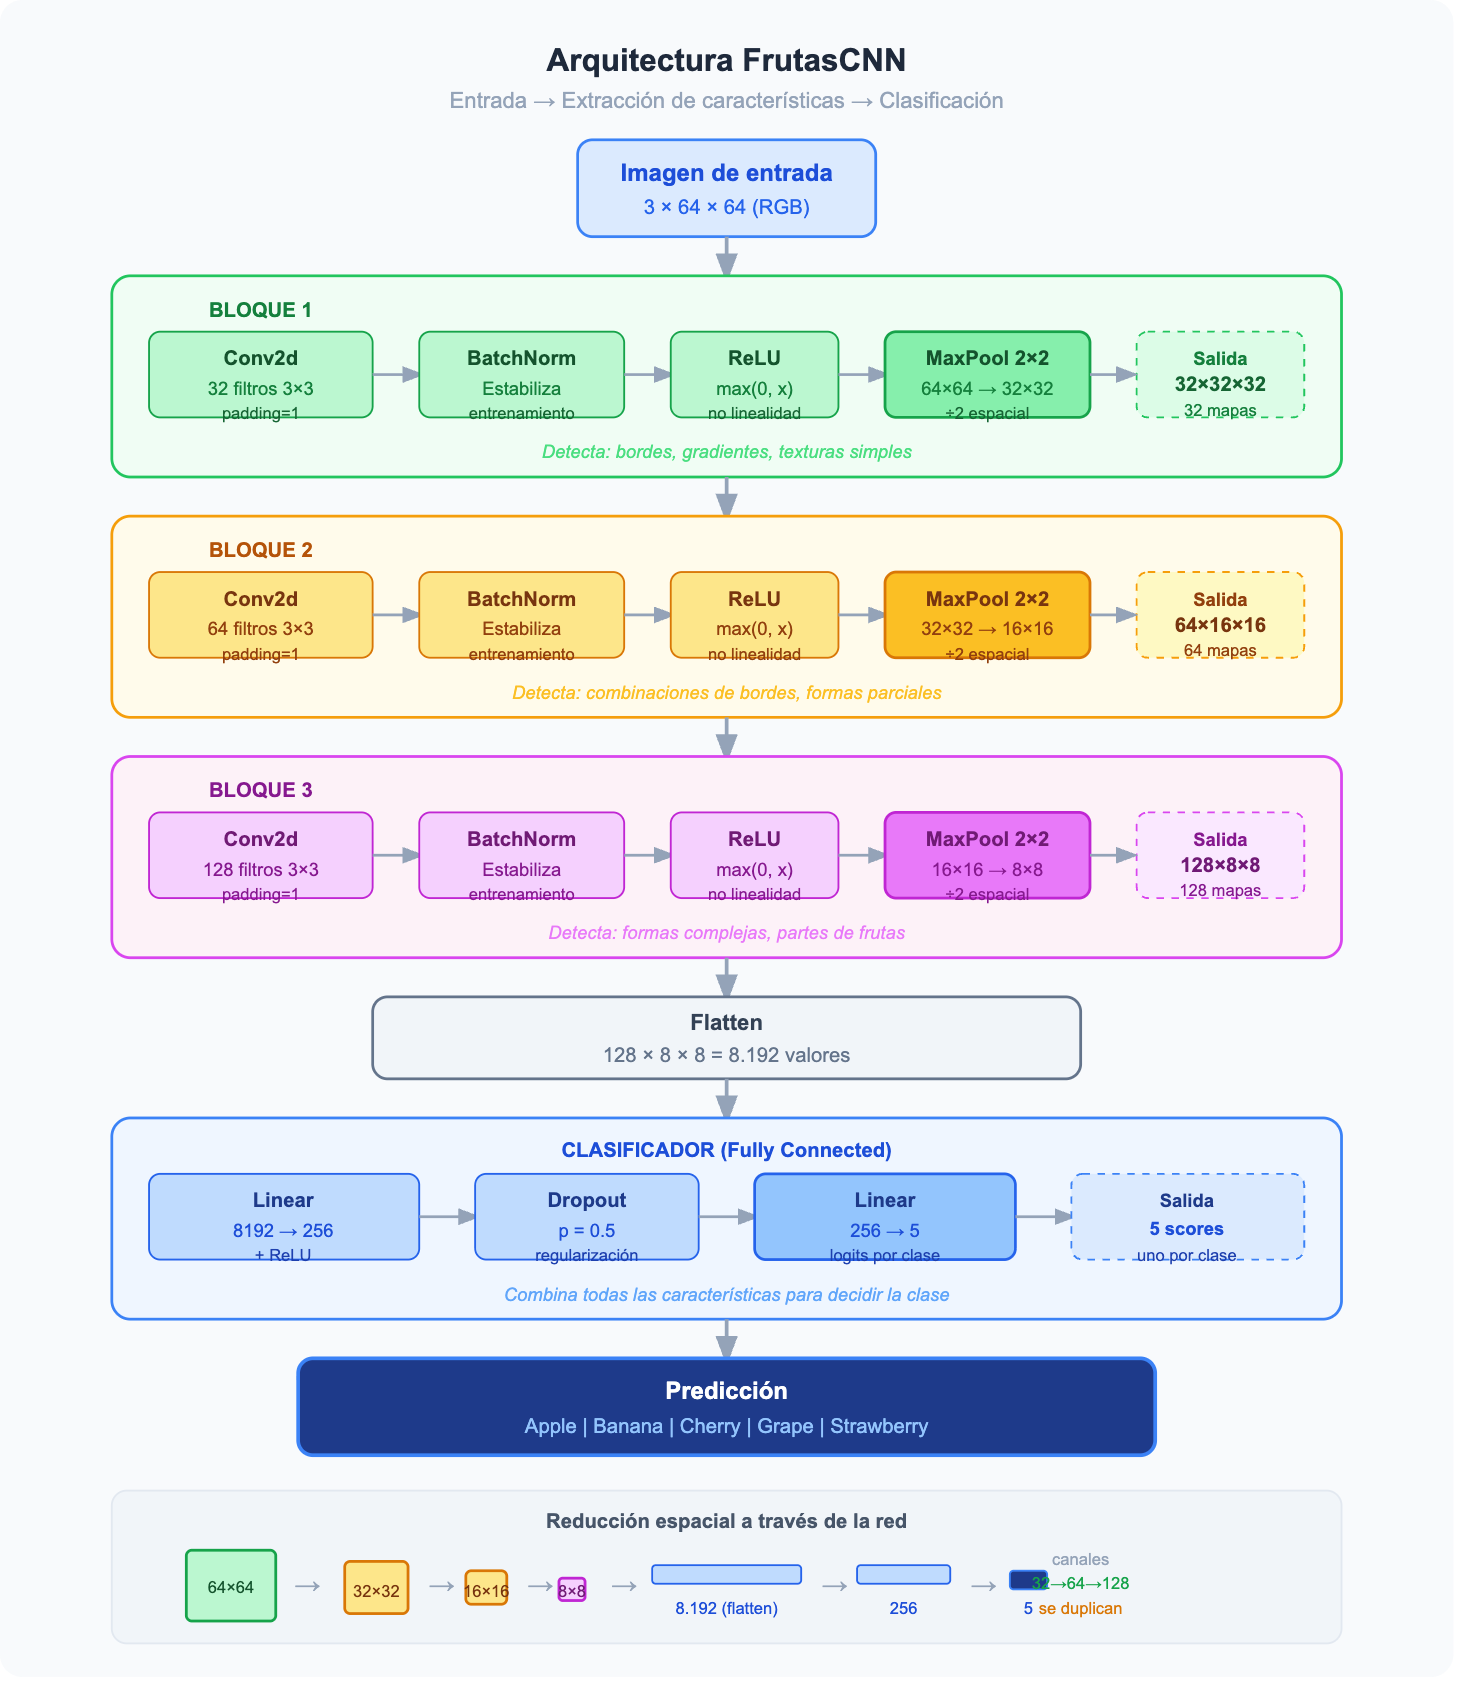


In [20]:
class FrutasCNN(nn.Module):
    """
    CNN para clasificación de frutas.
    Cada bloque duplica filtros (32->64->128) y reduce tamaño espacial con MaxPool.
    """
    def __init__(self, num_classes=5):
        super().__init__()
        # Bloque 1: detecta bordes y texturas simples
        self.bloque1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 3 canales RGB -> 32 mapas
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # 64x64 -> 32x32
        )
        # Bloque 2: detecta combinaciones de bordes
        self.bloque2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # 32x32 -> 16x16
        )
        # Bloque 3: detecta representaciones complejas
        self.bloque3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # 16x16 -> 8x8
        )
        # Clasificador final
        self.clasificador = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(p=0.5),   # Regularización contra overfitting
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.bloque1(x)
        x = self.bloque2(x)
        x = self.bloque3(x)
        return self.clasificador(x)

modelo = FrutasCNN(num_classes=NUM_CLASES).to(device)
total_params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(f'✅ Modelo creado | Parámetros entrenables: {total_params:,}')
print(modelo)


✅ Modelo creado | Parámetros entrenables: 2,192,389
FrutasCNN(
  (bloque1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (bloque2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (bloque3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (clasificador): Sequen

**Test rápido:**
Crea una imagen falsa y la pasa por el modelo para verificar que las dimensiones son correctas antes de entrenar con datos reales.

`torch.randn(4, 3, IMG_SIZE, IMG_SIZE)` genera números aleatorios con la misma forma que un batch real — 4 imágenes, 3 canales RGB, 64×64 píxeles. El contenido no importa, solo la forma.

Luego pasa ese tensor por el modelo y verifica que la salida tenga la forma correcta: [4, 5] — 4 imágenes, 5 scores (uno por fruta).

In [22]:
# Test rápido de dimensiones
with torch.no_grad():
    x = torch.randn(4, 3, IMG_SIZE, IMG_SIZE).to(device)
    y = modelo(x)
    print(f'✅ Test de dimensiones:')
    print(f'   Entrada:  {x.shape}')
    print(f'   Salida:   {y.shape}  → 1 score por clase')


✅ Test de dimensiones:
   Entrada:  torch.Size([4, 3, 64, 64])
   Salida:   torch.Size([4, 5])  → 1 score por clase


### Paso 1.5: Entrenamiento

El ciclo de entrenamiento por cada batch:
1. **Forward pass**: el modelo hace predicciones
2. **Loss**: medimos el error con CrossEntropyLoss
3. **Backward pass**: calculamos gradientes
4. **Update**: el optimizador ajusta los pesos


In [13]:
EPOCHS = 20
LR     = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelo.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

def entrenar_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correcto, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        _, preds = out.max(1)
        total_loss += loss.item() * imgs.size(0)
        correcto   += preds.eq(labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correcto / total

@torch.no_grad()
def evaluar(model, loader, criterion, device):
    model.eval()
    total_loss, correcto, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        out = model(imgs)
        loss = criterion(out, labels)
        _, preds = out.max(1)
        total_loss += loss.item() * imgs.size(0)
        correcto   += preds.eq(labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correcto / total

# Bucle principal
historial = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
mejor_val_loss = float('inf')
CKPT_PATH = '/content/mejor_modelo.pth'

print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>10} | {"Val Loss":>10} | {"Val Acc":>10}')
print('-' * 58)

for epoch in range(1, EPOCHS + 1):
    tl, ta = entrenar_epoch(modelo, train_loader, criterion, optimizer, device)
    vl, va = evaluar(modelo, val_loader, criterion, device)
    scheduler.step(vl)
    for k, v in [('train_loss',tl),('val_loss',vl),('train_acc',ta),('val_acc',va)]:
        historial[k].append(v)
    marca = ''
    if vl < mejor_val_loss:
        mejor_val_loss = vl
        torch.save({'epoch':epoch, 'model_state_dict':modelo.state_dict(),
                    'val_acc':va, 'class_names':class_names}, CKPT_PATH)
        marca = ' ✅'
    print(f'{epoch:>6} | {tl:>10.4f} | {ta:>9.1%} | {vl:>10.4f} | {va:>9.1%}{marca}')


 Epoch | Train Loss |  Train Acc |   Val Loss |    Val Acc
----------------------------------------------------------
     1 |     0.4551 |     86.4% |     0.0909 |     95.2% ✅
     2 |     0.0596 |     98.2% |     0.0002 |    100.0% ✅
     3 |     0.0718 |     97.9% |     0.0046 |    100.0%
     4 |     0.0379 |     98.7% |     0.0249 |     99.5%
     5 |     0.0310 |     99.0% |     0.0027 |    100.0%
     6 |     0.0369 |     98.8% |     0.0007 |    100.0%
     7 |     0.0107 |     99.6% |     0.0166 |     99.5%
     8 |     0.0220 |     99.4% |     0.2034 |     90.0%
     9 |     0.0206 |     99.4% |     0.0009 |    100.0%
    10 |     0.0124 |     99.7% |     0.0052 |    100.0%
    11 |     0.0291 |     99.1% |     0.0373 |     97.8%
    12 |     0.0081 |     99.8% |     0.0904 |     96.2%
    13 |     0.0118 |     99.7% |     0.1012 |     95.2%
    14 |     0.0068 |     99.6% |     0.0004 |    100.0%
    15 |     0.0031 |     99.9% |     0.0001 |    100.0% ✅
    16 |     0.0149 |

### Paso 1.6: Curvas de aprendizaje y evaluación

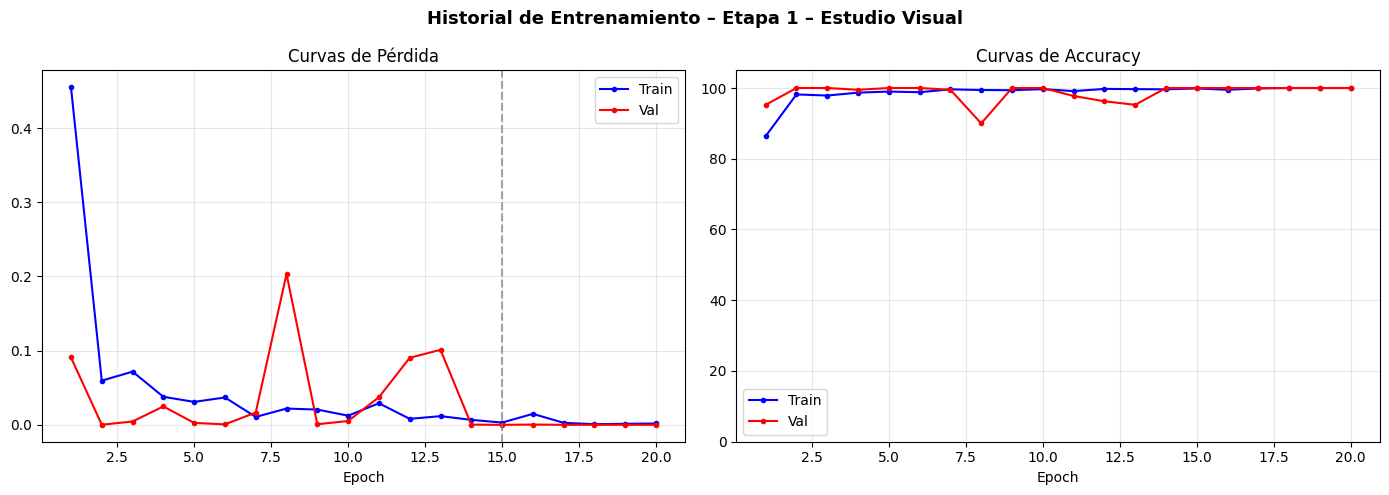

Mejor Val Accuracy: 100.00% (epoch 2)


In [14]:
def graficar_historial(hist, titulo='Etapa 1 – Estudio Visual'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ep = range(1, len(hist['train_loss'])+1)
    ax1.plot(ep, hist['train_loss'], 'b-o', ms=3, label='Train')
    ax1.plot(ep, hist['val_loss'],   'r-o', ms=3, label='Val')
    ax1.axvline(x=np.argmin(hist['val_loss'])+1, color='gray', ls='--', alpha=0.7)
    ax1.set_title('Curvas de Pérdida'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(ep, [a*100 for a in hist['train_acc']], 'b-o', ms=3, label='Train')
    ax2.plot(ep, [a*100 for a in hist['val_acc']],   'r-o', ms=3, label='Val')
    ax2.set_title('Curvas de Accuracy'); ax2.set_xlabel('Epoch'); ax2.set_ylim([0,105])
    ax2.legend(); ax2.grid(alpha=0.3)
    plt.suptitle(f'Historial de Entrenamiento – {titulo}', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()
    print(f'Mejor Val Accuracy: {max(hist["val_acc"])*100:.2f}% (epoch {np.argmax(hist["val_acc"])+1})')

graficar_historial(historial)


In [15]:
@torch.no_grad()
def obtener_predicciones(model, loader, device):
    model.eval()
    preds_all, labels_all = [], []
    for imgs, labels in loader:
        out = model(imgs.to(device))
        _, preds = out.max(1)
        preds_all.extend(preds.cpu().numpy())
        labels_all.extend(labels.numpy())
    return np.array(preds_all), np.array(labels_all)

# Cargar mejor modelo
ckpt = torch.load(CKPT_PATH, map_location=device)
modelo.load_state_dict(ckpt['model_state_dict'])
print(f'✅ Mejor modelo cargado (epoch {ckpt["epoch"]}, val_acc={ckpt["val_acc"]:.2%})')

preds, labels_reales = obtener_predicciones(modelo, test_loader, device)
print(f'\nTest Accuracy: {(preds==labels_reales).mean():.2%}\n')
print(classification_report(labels_reales, preds, target_names=[c.split()[0] for c in class_names]))


✅ Mejor modelo cargado (epoch 15, val_acc=100.00%)

Test Accuracy: 95.52%

              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00       160
      Banana       1.00      1.00      1.00       166
      Cherry       1.00      1.00      1.00       164
       Grape       1.00      0.87      0.93       328
  Strawberry       0.79      1.00      0.88       164

    accuracy                           0.96       982
   macro avg       0.96      0.97      0.96       982
weighted avg       0.96      0.96      0.96       982



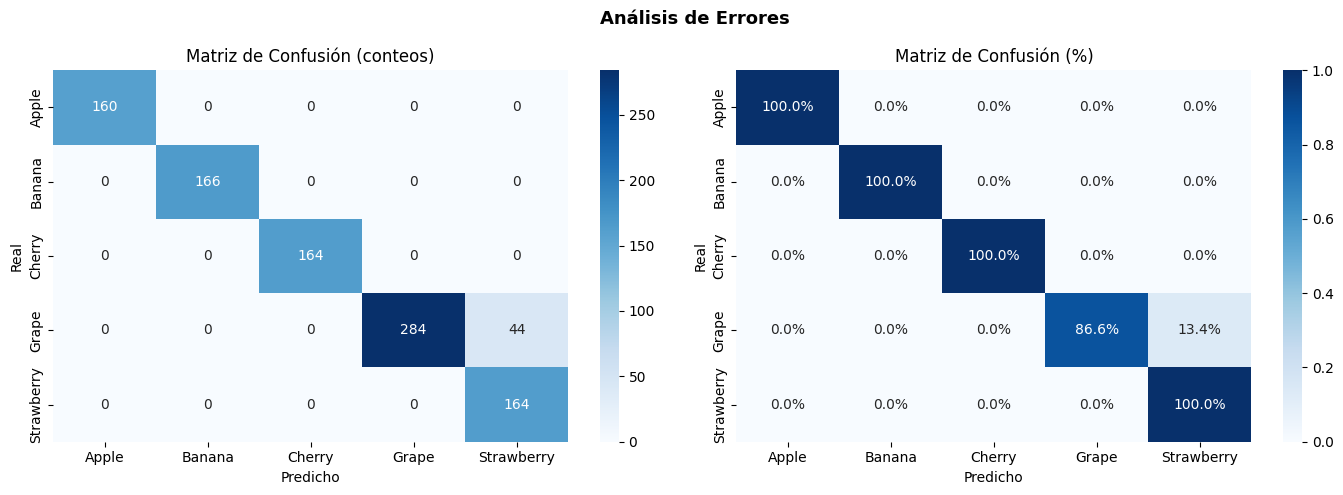

In [16]:
def graficar_confusion(preds, labels, class_names):
    nombres = [c.split()[0] for c in class_names]
    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, None]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(cm,      annot=True, fmt='d',    cmap='Blues', xticklabels=nombres, yticklabels=nombres, ax=ax1)
    sns.heatmap(cm_norm, annot=True, fmt='.1%',  cmap='Blues', xticklabels=nombres, yticklabels=nombres, ax=ax2)
    ax1.set_title('Matriz de Confusión (conteos)');   ax1.set_ylabel('Real'); ax1.set_xlabel('Predicho')
    ax2.set_title('Matriz de Confusión (%)');        ax2.set_ylabel('Real'); ax2.set_xlabel('Predicho')
    plt.suptitle('Análisis de Errores', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

graficar_confusion(preds, labels_reales, class_names)


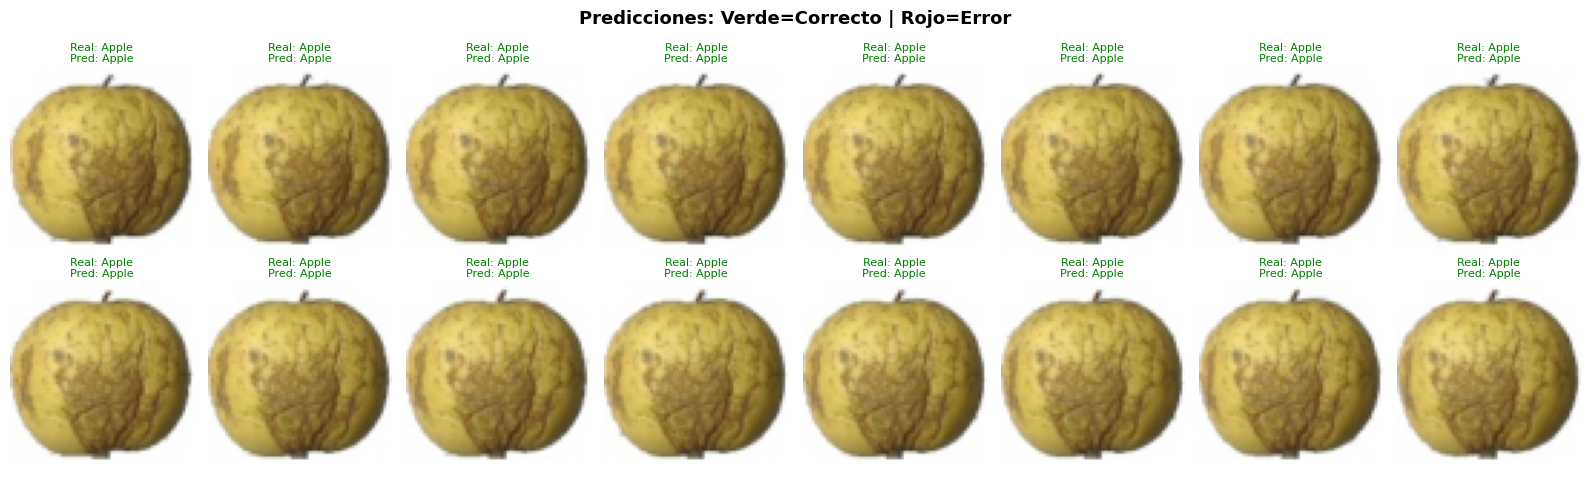

In [23]:
def visualizar_predicciones(model, loader, class_names, device, n=16):
    """Muestra predicciones: verde=correcto, rojo=error."""
    model.eval()
    imgs_b, labels_b = next(iter(loader))
    with torch.no_grad():
        _, preds = model(imgs_b.to(device)).max(1)
    mean = torch.tensor(MEAN).view(3,1,1); std = torch.tensor(STD).view(3,1,1)
    imgs_d = (imgs_b * std + mean).clamp(0, 1)
    nombres = [c.split()[0] for c in class_names]
    cols = 8; rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2.5))
    axes = axes.flatten()
    for i in range(min(n, len(imgs_d))):
        img = imgs_d[i].permute(1,2,0).numpy()
        real  = nombres[labels_b[i]]
        pred  = nombres[preds[i].cpu()]
        ok = (labels_b[i] == preds[i].cpu())
        axes[i].imshow(img)
        axes[i].set_title(f'Real: {real}\nPred: {pred}', fontsize=8, color='green' if ok else 'red', fontweight='bold' if not ok else 'normal')
        axes[i].axis('off')
    for j in range(i+1, len(axes)): axes[j].axis('off')
    plt.suptitle('Predicciones: Verde=Correcto | Rojo=Error', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

visualizar_predicciones(modelo, test_loader, class_names, device)


---
# 🍓 ETAPA 2: Dataset UTN-IA 2026
## El desafío de generalización

Usamos el mismo modelo con un dataset con fondos variables e iluminación real.
El modelo obtendrá **peor desempeño**. Esta es la lección más importante:

> **El dataset determina tanto o más que la arquitectura.**

**Dataset:** UTN-IA 2026 · Food Classification - Training Set  
**Link:** https://www.kaggle.com/datasets/geronimoforconi/utn-ia-2026-food-classification-training-set  
**Licencia:** Apache 2.0

> ⚠️ Este es el **dataset oficial de la competencia**. Las imágenes de test tienen fondos variados — el mismo modelo que obtuvo ~95% en Etapa 1 verá aquí cómo la distribución del dataset impacta el rendimiento real.


In [24]:
!kaggle datasets download -d geronimoforconi/utn-ia-2026-food-classification-training-set \
    -p /Users/Admin/Desktop/Estudios/Sistemas-2026/IA/Practica/Clase_3/fruit_recognition --unzip -q
print("✅ Dataset UTN-IA 2026 descargado")

raiz_r = Path("/Users/Admin/Desktop/Estudios/Sistemas-2026/IA/Practica/Clase_3/fruit_recognition")
for split in sorted(raiz_r.iterdir()):
    if split.is_dir():
        clases = [c for c in split.iterdir() if c.is_dir()]
        n_imgs = sum(len(list(c.glob("*.*"))) for c in clases)
        print(f"  {split.name}/: {len(clases)} clases, ~{n_imgs} imgs")


Dataset URL: https://www.kaggle.com/datasets/geronimoforconi/utn-ia-2026-food-classification-training-set
License(s): apache-2.0
✅ Dataset UTN-IA 2026 descargado
  train/: 5 clases, ~325 imgs


✅ Subset realista creado


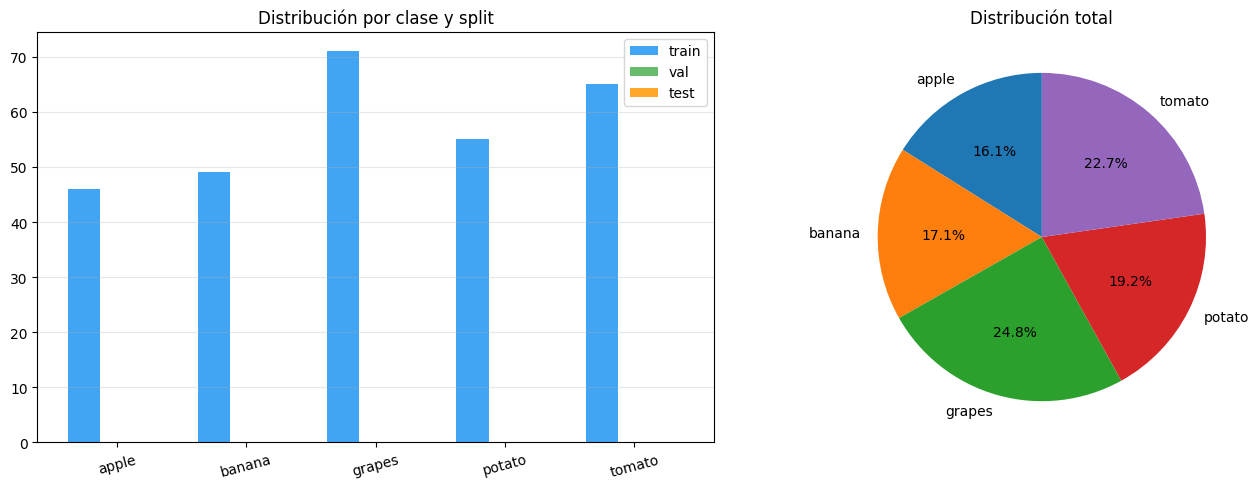

Clase                     Train      Val     Test
--------------------------------------------------
apple                        46        0        0
banana                       49        0        0
grapes                       71        0        0
potato                       55        0        0
tomato                       65        0        0


In [25]:
# Seleccionar mismas frutas que en Etapa 1 para comparación directa
CLASES_R = ['apple', 'banana', 'grapes', 'potato', 'tomato']
BASE_DIR_R = Path('/Users/Admin/Desktop/Estudios/Sistemas-2026/IA/Practica/Clase_3/frutas_realistas')

for split, split_src_name in [('train','train'), ('val','validation'), ('test','test')]:
    src_base = raiz_r / split_src_name
    if not src_base.exists(): continue
    for clase in CLASES_R:
        src = src_base / clase
        if src.exists():
            dst = BASE_DIR_R / split / clase
            dst.mkdir(parents=True, exist_ok=True)
            for img in src.glob('*.*'):
                if img.suffix.lower() in ['.jpg','.jpeg','.png']:
                    shutil.copy(img, dst / img.name)

print('✅ Subset realista creado')
analizar_distribucion(BASE_DIR_R)


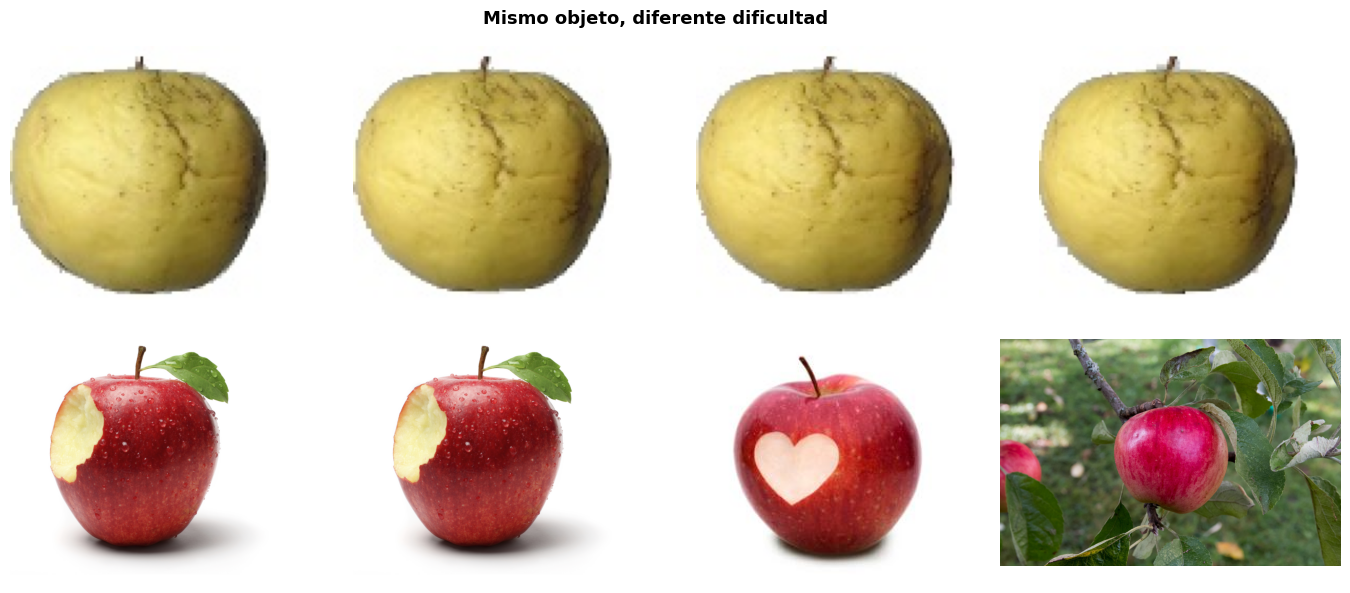

In [26]:
# Comparación visual: Etapa 1 (Estudio Visual) vs Etapa 2 (Training Set)
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for row, (base, clase, titulo) in enumerate([
    (BASE_DIR,   CLASES_SELECCIONADAS[0], 'UTN-IA 2026 · Estudio Visual - Etapa 1'),
    (BASE_DIR_R, CLASES_R[0],             'Dataset Realista')
]):
    carpeta = base / 'train' / clase
    imgs = list(carpeta.glob('*.jpg'))[:4] or list(carpeta.glob('*.png'))[:4]
    for col, img_path in enumerate(imgs[:4]):
        axes[row][col].imshow(Image.open(img_path))
        axes[row][col].axis('off')
        if col == 0: axes[row][col].set_ylabel(titulo, fontsize=10, fontweight='bold')
plt.suptitle('Mismo objeto, diferente dificultad', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


In [ ]:
# Augmentation más agresivo para el dataset realista (pocos datos, más variabilidad)
transform_train_r = transforms.Compose([
    transforms.Resize((IMG_SIZE+16, IMG_SIZE+16)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.2),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

#algunas imagenes estaban con formato transparente

from PIL import Image

def cargar_imagen_limpia(path):
    img = Image.open(path)
    # Convertir formatos problemáticos a RGB estándar
    if img.mode in ('P', 'RGBA', 'LA'):
        img = img.convert('RGBA')
        fondo = Image.new('RGB', img.size, (255, 255, 255))
        fondo.paste(img, mask=img.split()[3])  # usar canal alpha como máscara
        return fondo
    return img.convert('RGB')

train_r = ImageFolder(str(BASE_DIR_R/'train'), transform=transform_train_r, loader=cargar_imagen_limpia)
val_r   = ImageFolder(str(BASE_DIR_R/'val'),   transform=transform_base, loader=cargar_imagen_limpia)
test_r  = ImageFolder(str(BASE_DIR_R/'test'),  transform=transform_base, loader=cargar_imagen_limpia)

train_loader_r = DataLoader(train_r, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader_r   = DataLoader(val_r,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader_r  = DataLoader(test_r,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

class_names_r = train_r.classes
print(f'✅ Dataset realista: train={len(train_r)} | val={len(val_r)} | test={len(test_r)}')


FileNotFoundError: [WinError 3] El sistema no puede encontrar la ruta especificada: '\\Users\\Admin\\Desktop\\Estudios\\Sistemas-2026\\IA\\Practica\\Clase_3\\frutas_realistas\\val'

In [ ]:
# Entrenar el MISMO modelo en el dataset realista
modelo_r = FrutasCNN(num_classes=len(class_names_r)).to(device)
optimizer_r = optim.Adam(modelo_r.parameters(), lr=1e-3, weight_decay=1e-3)  # mayor regularización
scheduler_r = optim.lr_scheduler.ReduceLROnPlateau(optimizer_r, patience=5, factor=0.5)

historial_r = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
mejor_r = float('inf'); CKPT_R = '/content/mejor_modelo_realista.pth'

print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>10} | {"Val Loss":>10} | {"Val Acc":>10}')
print('-'*58)

for epoch in range(1, EPOCHS+1):
    tl, ta = entrenar_epoch(modelo_r, train_loader_r, criterion, optimizer_r, device)
    vl, va = evaluar(modelo_r, val_loader_r, criterion, device)
    scheduler_r.step(vl)
    for k, v in [('train_loss',tl),('val_loss',vl),('train_acc',ta),('val_acc',va)]:
        historial_r[k].append(v)
    marca = ''
    if vl < mejor_r:
        mejor_r = vl
        torch.save({'epoch':epoch, 'model_state_dict':modelo_r.state_dict(), 'val_acc':va}, CKPT_R)
        marca = ' ✅'
    print(f'{epoch:>6} | {tl:>10.4f} | {ta:>9.1%} | {vl:>10.4f} | {va:>9.1%}{marca}')


 Epoch | Train Loss |  Train Acc |   Val Loss |    Val Acc
----------------------------------------------------------
     1 |     2.7783 |     27.9% |     1.3314 |     47.9% ✅
     2 |     1.4638 |     43.2% |     1.1340 |     56.2% ✅
     3 |     1.3386 |     43.4% |     1.1019 |     58.3% ✅
     4 |     1.3054 |     47.6% |     1.0324 |     60.4% ✅
     5 |     1.2604 |     51.7% |     0.9922 |     60.4% ✅
     6 |     1.2575 |     47.1% |     0.9554 |     64.6% ✅
     7 |     1.2652 |     50.2% |     0.9843 |     64.6%
     8 |     1.2254 |     52.2% |     0.9805 |     66.7%
     9 |     1.2284 |     52.4% |     0.9292 |     62.5% ✅
    10 |     1.1539 |     56.1% |     0.8282 |     68.8% ✅
    11 |     1.2062 |     51.2% |     0.8594 |     66.7%
    12 |     1.1227 |     55.3% |     0.8307 |     68.8%
    13 |     1.1730 |     51.9% |     0.8073 |     75.0% ✅
    14 |     1.1520 |     52.2% |     0.9739 |     58.3%
    15 |     1.1686 |     54.9% |     0.9896 |     58.3%
    16 | 

### Comparación final: Dataset controlado vs. Realista

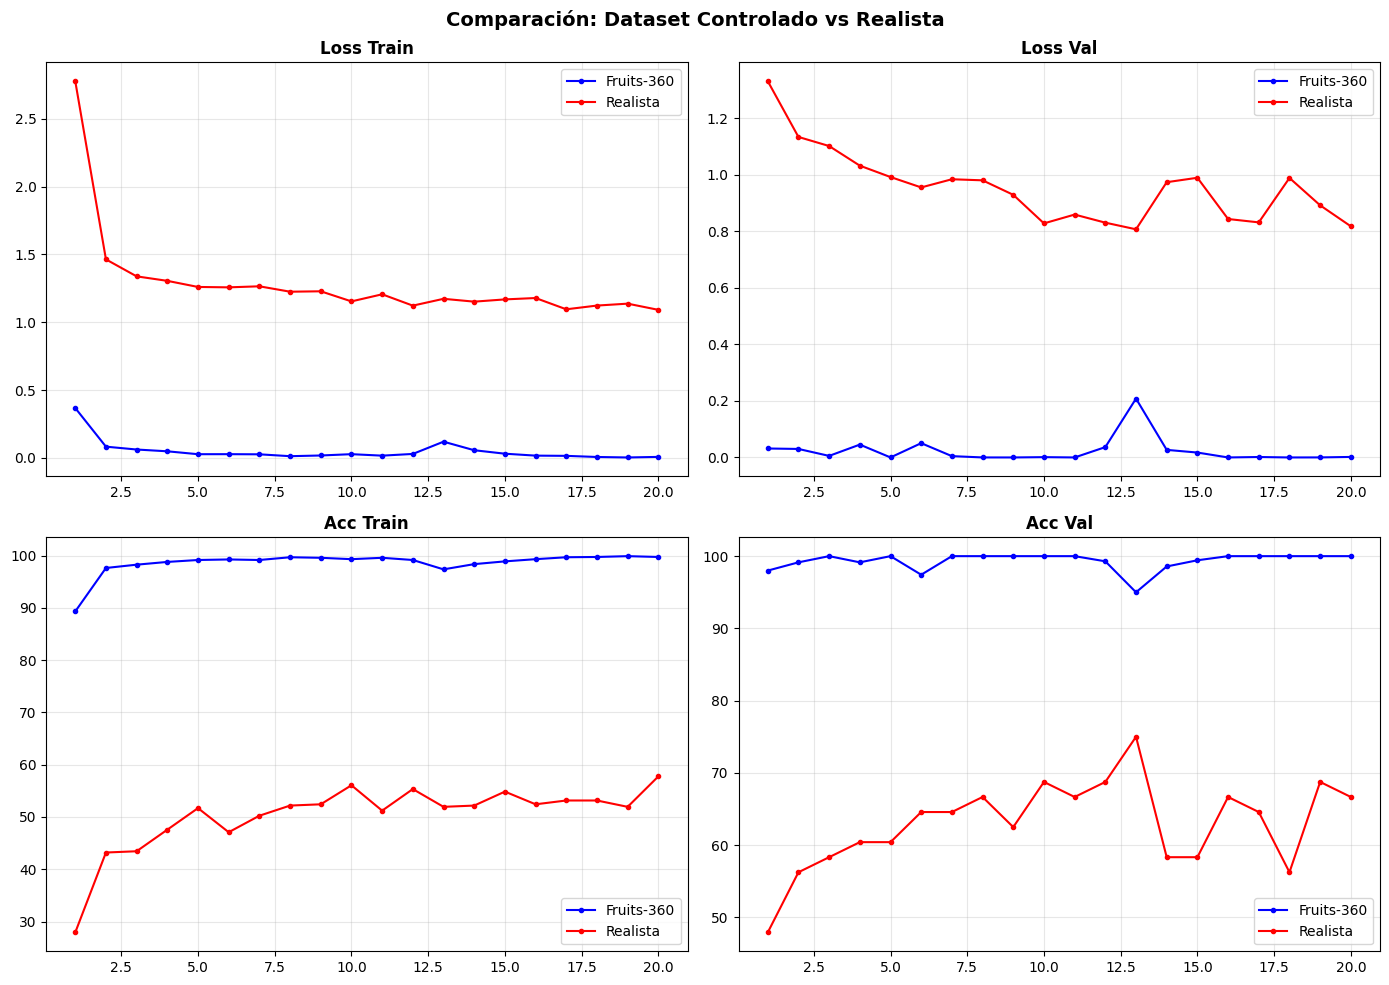

Dataset              Best Val Acc  Best Val Loss
------------------------------------------------
Fruits-360                100.00%         0.0000
Realista                   75.00%         0.8073

🎓 PREGUNTAS PARA LA CLASE:

  1. ¿Por qué el mismo modelo obtiene resultados tan diferentes?
  2. ¿Qué estrategias usarías para mejorar el modelo realista?
  3. ¿Por qué el augmentation más agresivo ayuda más en Etapa 2?
  4. ¿Qué es transfer learning y cómo ayudaría aquí?



In [ ]:
def comparar_resultados(h1, h2, label1='Etapa 1 – Estudio Visual', label2='Realista'):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    keys = [('train_loss','Loss Train'),('val_loss','Loss Val'),('train_acc','Acc Train'),('val_acc','Acc Val')]
    for ax, (key, titulo) in zip(axes.flatten(), keys):
        v1 = [x*100 for x in h1[key]] if 'acc' in key else h1[key]
        v2 = [x*100 for x in h2[key]] if 'acc' in key else h2[key]
        ax.plot(range(1,len(v1)+1), v1, 'b-o', ms=3, label=label1)
        ax.plot(range(1,len(v2)+1), v2, 'r-o', ms=3, label=label2)
        ax.set_title(titulo, fontweight='bold'); ax.legend(); ax.grid(alpha=0.3)
    plt.suptitle('Comparación: Dataset Controlado vs Realista', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()
    print(f'{"Dataset":<20} {"Best Val Acc":>12} {"Best Val Loss":>14}')
    print('-'*48)
    print(f'{label1:<20} {max(h1["val_acc"])*100:>11.2f}% {min(h1["val_loss"]):>14.4f}')
    print(f'{label2:<20} {max(h2["val_acc"])*100:>11.2f}% {min(h2["val_loss"]):>14.4f}')

comparar_resultados(historial, historial_r)

print('\n' + '='*60)
print('🎓 PREGUNTAS PARA LA CLASE:')
print('='*60)
print("""
  1. ¿Por qué el mismo modelo obtiene resultados tan diferentes?
  2. ¿Qué estrategias usarías para mejorar el modelo realista?
  3. ¿Por qué el augmentation más agresivo ayuda más en Etapa 2?
  4. ¿Qué es transfer learning y cómo ayudaría aquí?
""")


---
# 🏆 Submission para la Competencia Kaggle
## UTN-IA 2026: Fruit & Vegetable Classifier

Una vez entrenado el modelo en Etapa 2, generamos el archivo `submission.csv` para subirlo a la competencia.

**Competencia:** https://www.kaggle.com/competitions/utn-ia-2026-fruit-vegetable-classifier

**Formato requerido:**
```
image_id,label
img_0001.jpg,apple
img_0002.jpg,tomato
...
```

**Clases válidas:** `apple`, `banana`, `grapes`, `potato`, `tomato`


In [ ]:
# Descargar las imágenes de test de la competencia
!kaggle competitions download -c utn-ia-2026-fruit-vegetable-classifier \
    -f utn_competencia_test.zip -p /content/data/test_competencia -q
!unzip -q /content/data/test_competencia/utn_competencia_test.zip \
    -d /content/data/test_competencia/

DIR_TEST = Path("/content/data/test_competencia")
imagenes_test = sorted([p for p in DIR_TEST.rglob("*") if p.suffix.lower() in [".jpg",".jpeg",".png"]])
print(f"✅ {len(imagenes_test)} imágenes de test listas para predecir")


In [ ]:
import pandas as pd

# Clases válidas en el mismo orden que el modelo fue entrenado
CLASES_COMP = ["apple", "banana", "grapes", "potato", "tomato"]

# Usar el modelo entrenado en Etapa 2 (modelo_r)
# Si querés usar el de Etapa 1, reemplazá modelo_r por modelo
modelo_submit = modelo_r
modelo_submit.eval()

predicciones = []

with torch.no_grad():
    for img_path in imagenes_test:
        img = Image.open(img_path).convert("RGB")
        tensor = transform_base(img).unsqueeze(0).to(device)
        logits = modelo_submit(tensor)
        pred_idx = logits.argmax(dim=1).item()
        pred_label = class_names_r[pred_idx]  # nombre de clase del modelo
        # Normalizar al nombre exacto de la competencia
        pred_label = pred_label.lower().strip()
        predicciones.append({
            "image_id": img_path.name,
            "label": pred_label
        })

df_sub = pd.DataFrame(predicciones)
print(df_sub.head(10))
print(f"Distribución de predicciones:")
print(df_sub["label"].value_counts())


In [ ]:
# Validar que todas las clases predichas son válidas
clases_invalidas = df_sub[~df_sub["label"].isin(CLASES_COMP)]
if len(clases_invalidas) > 0:
    print(f"⚠️ {len(clases_invalidas)} predicciones con clases inválidas:")
    print(clases_invalidas)
else:
    print(f"✅ Todas las {len(df_sub)} predicciones tienen clases válidas")

# Guardar submission.csv
df_sub.to_csv("/content/submission.csv", index=False)
print("
📄 submission.csv guardado")
print("  → Subilo en: https://www.kaggle.com/competitions/utn-ia-2026-fruit-vegetable-classifier/submit")


---
## Conclusiones

1. **El dataset importa tanto como la arquitectura** — UTN-IA 2026 · Estudio Visual - Etapa 1 (aprox 95%) vs. dataset realista (aprox 75%) con el mismo modelo.
2. **Data Augmentation = regularización** — no solo aumenta datos, enseña robustez al modelo.
3. **Las métricas deben complementarse** — accuracy + F1 + matriz de confusión dan una imagen completa.

## 🎯 Trabajo Práctico: subir el puntaje en la competencia

Con el notebook de clase tenés un baseline. Para el TP, explorá:

- **Transfer Learning** — ResNet18, EfficientNet, ViT preentrenados en ImageNet
- **Data Augmentation agresivo** — MixUp, CutMix, RandAugment
- **Fine-tuning** — descongelar capas del backbone gradualmente
- **Ensemble** — promediar predicciones de varios modelos
- **Test-Time Augmentation (TTA)** — predecir con múltiples crops/flips y promediar

**Métrica:** F1 Score Weighted — penaliza clases minoritarias mal predichas.
**URL competencia:** https://www.kaggle.com/competitions/utn-ia-2026-fruit-vegetable-classifier
